Paper:

https://arxiv.org/abs/2203.11171

Universal Self Consistency1 aims to extend self-consistency by using a second LLM model to judge the quality of individual responses. Therefore instead of choosing the final answer based on the most frequently occuring value among each reasoning chain, we instead prompt the model to choose the most consistent answer for us relative to the prompt.

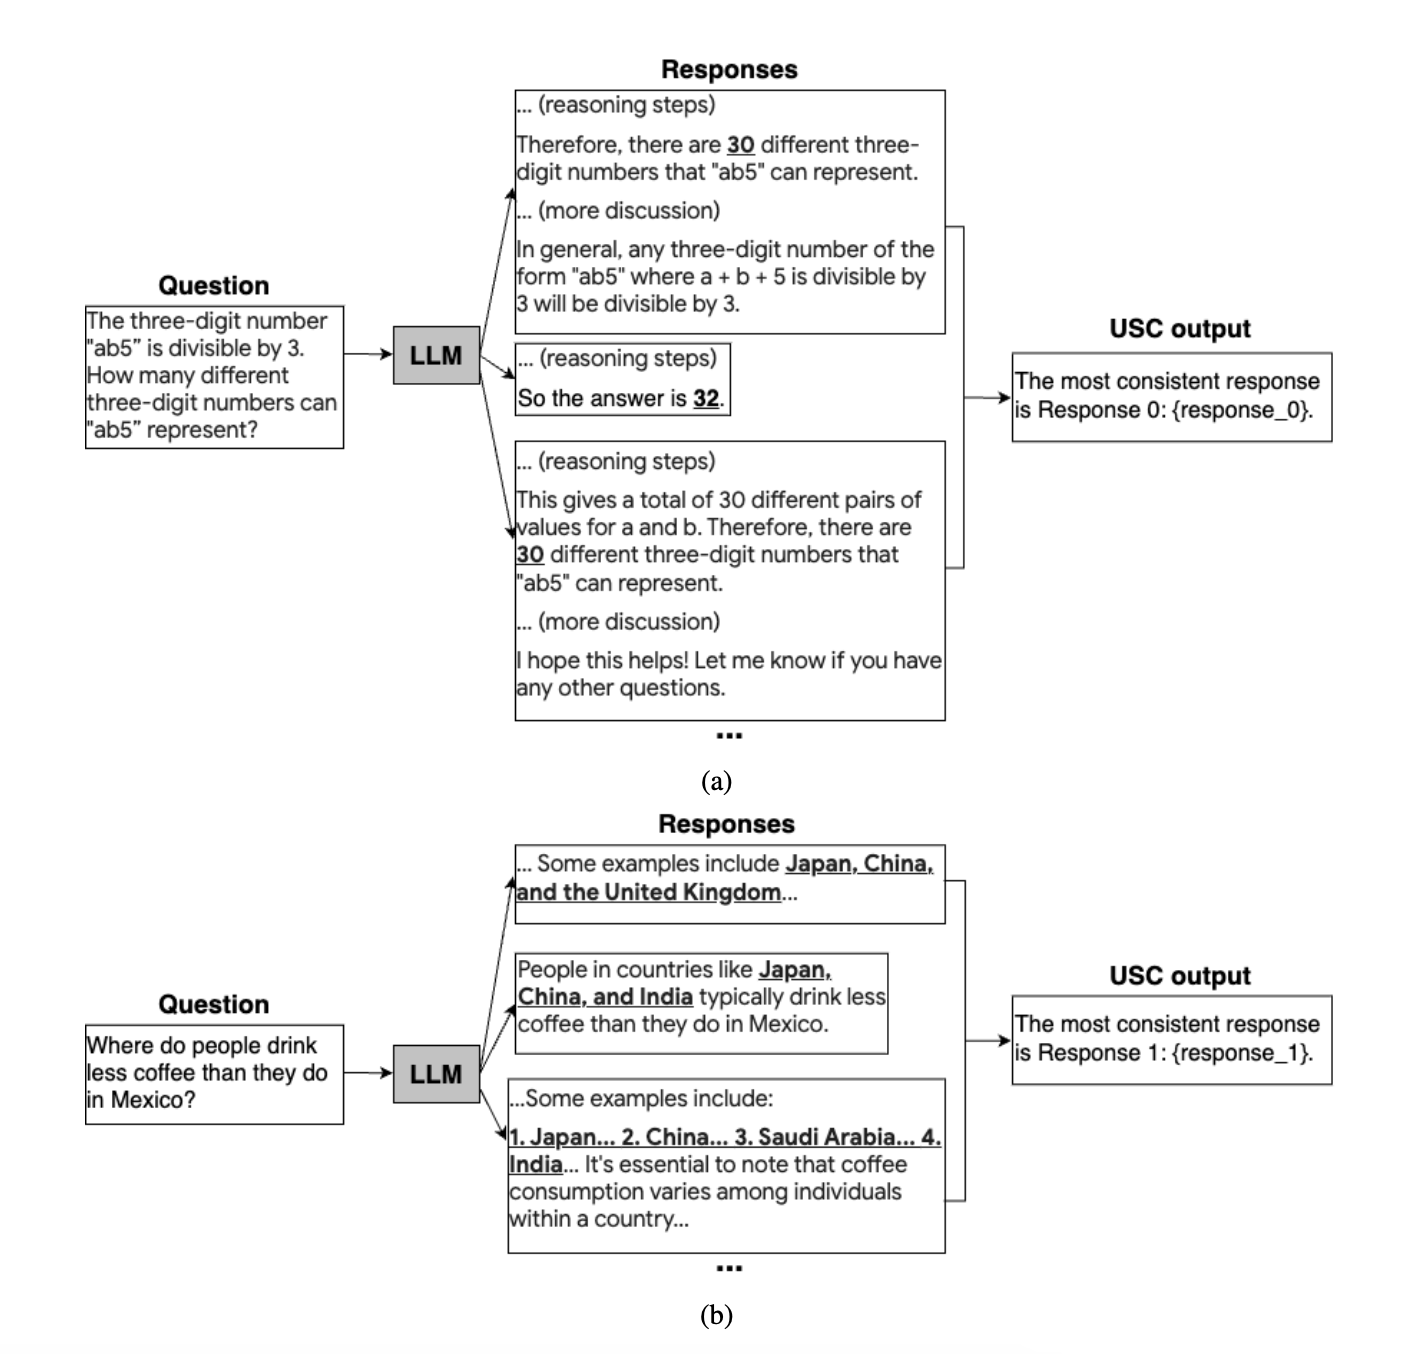

In [4]:
from pydantic import BaseModel, Field, ValidationInfo, field_validator
import instructor
from textwrap import dedent
import asyncio
import os
from dotenv import load_dotenv
from textwrap import dedent

load_dotenv(os.path.join("..", ".env"), override=True)
# Cliente
client = instructor.from_provider("openai/gpt-5", async_client=True)

In [2]:
# Models
class Response(BaseModel):
    reasoning: str  # razonamiento resumido, no chain-of-thought completo
    answer: str


class SelectedResponse(BaseModel):
    most_consistent_response_id: int = Field(
        description="ID of the most consistent response"
    )

    @field_validator("most_consistent_response_id")
    @classmethod
    def validate_id(cls, v: int, info: ValidationInfo):
        context = info.context or {}
        n = context.get("number_responses", 0)

        if not (0 <= v < n):
            raise ValueError(f"Invalid ID {v}. Must be between 0 and {n-1}")
        return v

In [6]:
# Core functions
async def generate_response(query: str) -> Response:
    return await client.create(
        model="gpt-4o-mini",
        response_model=Response,
        temperature=0.7,
        messages=[
            {
                "role": "system",
                "content": (
                    "Solve the problem. Provide a SHORT structured reasoning "
                    "(key steps only, no long explanation), and the final answer."
                ),
            },
            {"role": "user", "content": query},
        ],
    )

async def generate_batch_responses(query: str, n: int):
    tasks = [generate_response(query) for _ in range(n)]
    return await asyncio.gather(*tasks)

async def select_consistent_response(responses: list[Response], query: str):
    formatted = "\n\n".join(
        [
            f"""Response {i}:
Reasoning: {r.reasoning}
Answer: {r.answer}"""
            for i, r in enumerate(responses)
        ]
    )

    return await client.create(
        model="gpt-5-mini",
        response_model=SelectedResponse,
        messages=[
            {
                "role": "system",
                "content": (
                    "Select the most reliable answer. Use reasoning consistency, "
                    "mathematical correctness, and agreement between responses."
                ),
            },
            {
                "role": "user",
                "content": dedent(f"""
                Query:
                {query}

                Candidate responses:
                {formatted}

                Select the best response ID.
                """),
            },
        ],
        context={"number_responses": len(responses)},
    )

In [7]:
query = """The three-digit number 'ab5' is divisible by 3.
How many different three-digit numbers can 'ab5' represent?"""

responses = await generate_batch_responses(query, 5)

print("\n--- RESPONSES ---")
for r in responses:
    print(r.model_dump_json(indent=2))

selected = await select_consistent_response(responses, query)

print("\n--- SELECTED ---")
print(selected.model_dump_json(indent=2))

print("\n--- FINAL ---")
print(responses[selected.most_consistent_response_id].model_dump_json(indent=2))


--- RESPONSES ---
{
  "reasoning": "A number is divisible by 3 if the sum of its digits is divisible by 3. For the number 'ab5', the sum of the digits is a + b + 5. Therefore, we need to find the values of a (0-9) and b (0-9) such that a + b + 5 is divisible by 3. Since 5 % 3 = 2, we need a + b to be congruent to 1 (mod 3). The possible pairs (a, b) that satisfy this condition are calculated, leading to combinations of a and b that result in valid three-digit numbers. The valid values for a (1 to 9) and b (0 to 9) are counted. After checking the pairs, there are 30 valid combinations that yield different three-digit numbers 'ab5'.",
  "answer": "30"
}
{
  "reasoning": "A number is divisible by 3 if the sum of its digits is divisible by 3. For 'ab5', the digits are a, b, and 5. The sum is a + b + 5. We need to find combinations of a (0-9) and b (0-9) such that (a + b + 5) % 3 = 0. Since 5 % 3 = 2, we need (a + b) % 3 = 1. We can find pairs (a, b) that satisfy this condition and count t